In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import os
import cv2 
import os 

In [2]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator


Found 0 images belonging to 0 classes.


IndexError: index 0 is out of bounds for axis 0 with size 0

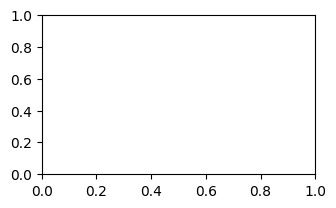

In [3]:
def dataset_train_processing():
    # Hardcode dataset path
    data_path =r'C:\SumMe\Frame\Bearpark_climbing'
    augmented_data_path = r'C:\SumMe\Augmentation\AugBe\Aug'
    
    # Create the directory for augmented data if it doesn't exist
    if not os.path.exists(augmented_data_path):
        os.makedirs(augmented_data_path)
    
    # Process dataset
    file_names = os.listdir(data_path)
    
    # Set a datagenerator for augmentation
    train_datagen = ImageDataGenerator(rotation_range=15,
                                       shear_range=0.1,
                                       zoom_range=0.2,
                                       horizontal_flip=True,
                                       width_shift_range=0.1,
                                       height_shift_range=0.1)
    
    # Create batches of data for augmentation
    for file_name in file_names:
        image_path = os.path.join(data_path, file_name)
        img = plt.imread(image_path)
        img = img.reshape((1,) + img.shape)  # Reshape to add batch dimension
        
        # Flow the image through the generator and save augmented images
        i = 0
        for batch in train_datagen.flow(img, 
                                        batch_size=1,
                                        save_to_dir=augmented_data_path,
                                        save_prefix=f'aug_{os.path.splitext(file_name)[0]}',
                                        save_format='jpeg'):
            i += 1
            if i >= 1:  # Save 2 augmented versions of each image
                break
    
    # Sample visualization of augmented images (optional)
    example_gen = train_datagen.flow_from_directory(data_path,
                                                    target_size=(224, 224),
                                                    batch_size=1,
                                                    class_mode=None,
                                                    save_to_dir=augmented_data_path,
                                                    save_prefix='aug_example',
                                                    save_format='jpg')
    
    plt.figure(figsize=(12, 12))
    for i in range(0, 15):
        plt.subplot(5, 3, i + 1)
        for X in example_gen:
            image = X[0]
            plt.imshow(image)
            break
    plt.tight_layout()
    plt.show()

# Usage
dataset_train_processing()

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import os

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
import numpy as np
import os

# Load the InceptionV3 model
net = InceptionV3(include_top=True, weights='imagenet')
net.summary()

# Load images from directory using ImageDataGenerator
image_directory = r'C:\SumMe\Augmentation\AugBe'
input_size = net.input_shape[1:3]  # Get the input size (height, width)

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
# Create a data generator for the images
augimds = datagen.flow_from_directory(image_directory,
                                      target_size=input_size,
                                      batch_size=32,  # Adjust the batch size if needed
                                      class_mode=None,
                                      shuffle=False) 

# Create a model that outputs the activations from the specified layer
layer_name = 'predictions'  # Example layer name in InceptionV3 (change as needed)
intermediate_layer_model = tf.keras.Model(inputs=net.input,
                                          outputs=net.get_layer(layer_name).output)

# Generate activations
features_train = intermediate_layer_model.predict(augimds)
# Reshape the features to ensure they are in 'rows' format (2D)
features_train = features_train.reshape(features_train.shape[0], -1)
np.save(os.path.join(image_directory, 'inceptionv3_features_train.npy'), features_train)

print(f"Features shape: {features_train.shape}")

# Print some sample features
print("Sample features (first 5 rows):")
print(features_train[:5])

Model: "inception_v3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 299, 299, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 149, 149, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 149, 149, 32  96         ['conv2d[0][0]']                 
 alization)                     )                                                      

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import os

In [7]:
# Load images from directory using ImageDataGenerator
image_directory = r'C:\SumMe\Augmentation\AugBe'
input_size = net.input_shape[1:3]  # Get the input size (height, width)

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
# Create a data generator for the images
augimds = datagen.flow_from_directory(image_directory,
                                      target_size=input_size,
                                      batch_size=32,  # Adjust the batch size if needed
                                      class_mode=None,
                                      shuffle=False) 

# Generate activations
features_train = intermediate_layer_model.predict(augimds)
# Create a model that outputs the activations from the specified layer
layer_name = 'predictions'  # Example layer name in ResNet50
intermediate_layer_model = tf.keras.Model(inputs=net.input,
                                          outputs=net.get_layer(layer_name).output)

# Generate activations
features_train = intermediate_layer_model.predict(augimds)
# Reshape the features to ensure they are in 'rows' format (2D)
features_train = features_train.reshape(features_train.shape[0], -1)
np.save(os.path.join(image_directory, 'resnet50_features_train.npy'), features_train)


print(f"Features shape: {features_train.shape}")

# Print some sample features
print("Sample features (first 5 rows):")
print(features_train[:5])

Found 3341 images belonging to 1 classes.
105/105 [==============================] - 236s 2s/step
Features shape: (3341, 1000)
Sample features (first 5 rows):
[[2.8226649e-10 2.1251576e-08 7.8399093e-13 ... 3.0446268e-10
  7.2044652e-17 5.5557708e-15]
 [2.6638626e-08 1.2208858e-11 1.6679097e-11 ... 1.1382799e-10
  1.6099744e-15 1.6004062e-12]
 [6.4747483e-09 3.0009524e-09 4.0365940e-11 ... 5.0341016e-09
  6.1162983e-15 4.1735200e-13]
 [1.0514118e-08 1.5396475e-07 9.7503658e-08 ... 1.2021043e-08
  8.0680747e-11 8.7641623e-11]
 [7.8434143e-10 1.9558775e-09 5.1904475e-12 ... 1.0140486e-07
  1.7563127e-13 2.3310882e-14]]


In [1]:
import numpy as np
import os

# Define the directory where your features are saved
image_directory = r'C:\SumMe\Augmentation\AugBe'

# Load the features from the saved .npy files
features_resnet = np.load(os.path.join(image_directory, 'resnet50_features_train.npy'))
features_inceptionv3 = np.load(os.path.join(image_directory, 'inceptionv3_features_train.npy'))

# Ensure both feature arrays have the same number of samples
assert features_resnet.shape[0] == features_inceptionv3.shape[0], "Number of samples must be the same in both feature arrays."

# Concatenate the features along the feature dimension (axis=1)
features_combined = np.concatenate((features_resnet, features_inceptionv3), axis=1)

# Save the combined features to a new .npy file
np.save(os.path.join(image_directory, 'combined_features_train.npy'), features_combined)

print(f"Combined features shape: {features_combined.shape}")

# Print some sample combined features
print("Sample combined features (first 5 rows):")
print(features_combined[:5])

Combined features shape: (3341, 2000)
Sample combined features (first 5 rows):
[[2.8226649e-10 2.1251576e-08 7.8399093e-13 ... 1.0853199e-04
  1.0640062e-03 9.0542097e-05]
 [2.6638626e-08 1.2208858e-11 1.6679097e-11 ... 2.9759092e-04
  2.4500693e-04 2.4355103e-04]
 [6.4747483e-09 3.0009524e-09 4.0365940e-11 ... 1.8881395e-04
  3.1610267e-04 4.4573925e-04]
 [1.0514118e-08 1.5396475e-07 9.7503658e-08 ... 2.6546195e-04
  3.1526387e-04 4.2455987e-04]
 [7.8434143e-10 1.9558775e-09 5.1904475e-12 ... 1.8472504e-04
  2.0261847e-04 3.4954821e-04]]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [3]:
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# Define the directory where your features are saved
image_directory = r'C:\SumMe\Augmentation\AugBe'

# Load the features from the saved .npy files
features_combined = np.load(os.path.join(image_directory, 'combined_features_train.npy'))

# Define the number of timesteps (sequence length) and features
timesteps = 1  # Assuming each sample is treated as a sequence of length 1 for this example
input_dim = features_combined.shape[1]  # Should be 2000

# Prepare data for LSTM
# For this example, we'll use the features directly as sequences of length 1
X = features_combined
y = np.random.randint(0, 100, size=(features_combined.shape[0],))  # Example target variable, replace with your actual labels

# Reshape input to be [samples, timesteps, features]
X = X.reshape((X.shape[0], timesteps, input_dim))

# Define the LSTM model
inputs = Input(shape=(timesteps, input_dim))

# Add LSTM layers
x = LSTM(64, return_sequences=True)(inputs)
x = Dropout(0.5)(x)

x = LSTM(128, return_sequences=True)(x)
x = Dropout(0.5)(x)

x = LSTM(256, return_sequences=True)(x)
x = Dropout(0.5)(x)

x = LSTM(256, return_sequences=True)(x)
x = Dropout(0.5)(x)

x = LSTM(128, return_sequences=True)(x)
x = Dropout(0.5)(x)

x = LSTM(64, return_sequences=True)(x)
x = Dropout(0.5)(x)

x = LSTM(32)(x)
x = Dropout(0.5)(x)

# Add a Dense layer for output
outputs = Dense(100, activation='softmax')(x)  # Adjust the number of units based on your specific task

# Create the model
model = Model(inputs=inputs, outputs=outputs)

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# Train the model
# For this example, we use dummy targets. Replace y with your actual labels.
model.fit(X, y, epochs=20, batch_size=32, validation_split=0.2)

# Extract features from the last LSTM layer
feature_extractor = Model(inputs=model.input, outputs=model.layers[-3].output)  # Layer before the final Dense layer

# Obtain features from the last LSTM layer
features_last_lstm = feature_extractor.predict(X)

# Save the extracted features
np.save(os.path.join(image_directory, 'features_last_lstm.npy'), features_last_lstm)

# Print the feature shape
print(f"Shape of features extracted from the last LSTM layer: {features_last_lstm.shape}")

# Print some sample features
print("Sample features from the last LSTM layer (first 5 samples):")
print(features_last_lstm[:5])

Epoch 1/20
84/84 [==============================] - 21s 96ms/step - loss: 4.6054 - accuracy: 0.0079 - val_loss: 4.6054 - val_accuracy: 0.0060
Epoch 2/20
84/84 [==============================] - 3s 40ms/step - loss: 4.6033 - accuracy: 0.0142 - val_loss: 4.6058 - val_accuracy: 0.0060
Epoch 3/20
84/84 [==============================] - 4s 43ms/step - loss: 4.6012 - accuracy: 0.0131 - val_loss: 4.6079 - val_accuracy: 0.0060
Epoch 4/20
84/84 [==============================] - 3s 40ms/step - loss: 4.5975 - accuracy: 0.0146 - val_loss: 4.6115 - val_accuracy: 0.0060
Epoch 5/20
84/84 [==============================] - 3s 40ms/step - loss: 4.5957 - accuracy: 0.0142 - val_loss: 4.6132 - val_accuracy: 0.0060
Epoch 6/20
84/84 [==============================] - 4s 43ms/step - loss: 4.5932 - accuracy: 0.0146 - val_loss: 4.6164 - val_accuracy: 0.0060
Epoch 7/20
84/84 [==============================] - 3s 40ms/step - loss: 4.5932 - accuracy: 0.0112 - val_loss: 4.6173 - val_accuracy: 0.0060
Epoch 8/20
8

In [4]:
import numpy as np
from sklearn.cluster import KMeans

# Load data (assuming the data is saved in a numpy array .npy file)
# Replace the path with the actual location of your data file
F = np.load(r"C:\SumMe\Augmentation\AugBe\features_last_lstm.npy")  # Adjust this path if necessary

# Set parameters
N = 501
np.random.seed(2)  # Setting the random seed for reproducibility

# Perform k-means clustering
kmeans = KMeans(n_clusters=N, init='k-means++', random_state=2)
kmeans.fit(F)

# Get cluster assignments (C_IDX) and cluster centroids (CC)
C_IDX = kmeans.labels_
CC = kmeans.cluster_centers_

# Initialize list to store indices of data points in each cluster
C = {i: np.where(C_IDX == i)[0] for i in range(N)}

# C now contains the indices of data points in each cluster


In [5]:
# Print the actual data points in the first cluster (cluster 0)
cluster_0_data_points = F[C[0], :]
print(cluster_0_data_points)


[[ 0.0054303   0.00056655 -0.01518568 -0.00218635  0.00970225 -0.01056128
  -0.00555637 -0.00787379  0.02939865  0.00393306  0.01856036 -0.01502769
  -0.01040332 -0.016193    0.00652173 -0.0255459   0.01990785  0.00243206
  -0.00841387  0.00518123  0.00491941  0.01745492 -0.01393976 -0.01158322
  -0.00914567  0.00461185  0.00468654  0.00601832  0.0014775   0.01313879
  -0.01950414  0.01390312]
 [ 0.00541812  0.00056564 -0.01516847 -0.0022045   0.00970103 -0.01055209
  -0.0055384  -0.00786531  0.02937355  0.00394568  0.01856559 -0.01502
  -0.01039697 -0.01618412  0.00654267 -0.02555026  0.0199051   0.00242531
  -0.00839699  0.0051577   0.00492091  0.01743939 -0.01395266 -0.01156932
  -0.00914016  0.0045963   0.00469714  0.00602611  0.00146559  0.01311953
  -0.01951149  0.01390259]
 [ 0.00501408  0.00052691 -0.01450481 -0.00286971  0.00965369 -0.01018258
  -0.00485006 -0.00750734  0.02844203  0.00444505  0.01880433 -0.01473555
  -0.01012357 -0.01584366  0.00732597 -0.02571797  0.01980898

In [6]:
# Print all the indices and their corresponding cluster values
for cluster_idx in range(N):
    print(f"Cluster {cluster_idx}:")
    print("Indices of data points:", C[cluster_idx])
    print("Number of data points in this cluster:", len(C[cluster_idx]))
    print()


Cluster 0:
Indices of data points: [ 391  744 1003 1325 1456 1627 2222 2298 2615 2648 2675 3150 3331]
Number of data points in this cluster: 13

Cluster 1:
Indices of data points: [ 109  838 1327 1619 2306 2597]
Number of data points in this cluster: 6

Cluster 2:
Indices of data points: [1999 2029 2540 2729]
Number of data points in this cluster: 4

Cluster 3:
Indices of data points: [ 211  235  558 1445 2285]
Number of data points in this cluster: 5

Cluster 4:
Indices of data points: [  33   96  118  359 1054 1740 2183 2899 2914 2983 3172]
Number of data points in this cluster: 11

Cluster 5:
Indices of data points: [ 934 1630 2286 2371]
Number of data points in this cluster: 4

Cluster 6:
Indices of data points: [  22   31   69  477  814 1137 1334 2201 2525 2865 2901 2954 3001 3218]
Number of data points in this cluster: 14

Cluster 7:
Indices of data points: [ 442  542 1016 1478 1561 2736]
Number of data points in this cluster: 6

Cluster 8:
Indices of data points: [ 937 1147 1641

In [7]:
import numpy as np
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

# Load data (assuming the data is saved in a numpy array .npy file)
try:
    F = np.load(r"C:\SumMe\Augmentation\AugBe\features_last_lstm.npy")  # Adjust this path if necessary
except FileNotFoundError:
    print("Error: The specified file was not found.")
    exit(1)

# Set parameters
N = 501  # Number of clusters
num_samples = F.shape[0]  # Number of data points (950)
np.random.seed(2)  # Setting the random seed for reproducibility

# Perform k-means clustering
kmeans = KMeans(n_clusters=N, init='k-means++', random_state=2)
kmeans.fit(F)

# Get cluster assignments (C_IDX) and cluster centroids (CC)
C_IDX = kmeans.labels_
CC = kmeans.cluster_centers_

# Initialize binary matrix (950 x 143) with zeros
keyframe_matrix = np.zeros((num_samples, N), dtype=int)

# Loop through each cluster and find the closest data point to the centroid
for cluster_idx in range(N):
    # Get the indices of the data points in the current cluster
    cluster_indices = np.where(C_IDX == cluster_idx)[0]
    
    # Skip empty clusters (if any)
    if len(cluster_indices) == 0:
        print(f"Cluster {cluster_idx} is empty, skipping.")
        continue
    
    # Get the feature vectors for the data points in this cluster
    cluster_features = F[cluster_indices, :]
    
    # Get the centroid of this cluster
    centroid = CC[cluster_idx]
    
    # Compute the Euclidean distance between each point in the cluster and the centroid
    distances = cdist(cluster_features, centroid.reshape(1, -1), metric='euclidean')
    
    # Get the index of the closest data point to the centroid
    closest_point_idx = cluster_indices[np.argmin(distances)]
    
    # Set the corresponding entry in the binary matrix to 1 (keyframe)
    keyframe_matrix[closest_point_idx, cluster_idx] = 1

    # Optionally, print the keyframe index for each cluster
    print(f"Cluster {cluster_idx}: Keyframe index: {closest_point_idx}")
# keyframe_matrix is now a 950 x 143 binary matrix
# You can use it for further analysis or saving to a file


Cluster 0: Keyframe index: 3150
Cluster 1: Keyframe index: 109
Cluster 2: Keyframe index: 2540
Cluster 3: Keyframe index: 235
Cluster 4: Keyframe index: 359
Cluster 5: Keyframe index: 2371
Cluster 6: Keyframe index: 31
Cluster 7: Keyframe index: 542
Cluster 8: Keyframe index: 937
Cluster 9: Keyframe index: 841
Cluster 10: Keyframe index: 2220
Cluster 11: Keyframe index: 1298
Cluster 12: Keyframe index: 1455
Cluster 13: Keyframe index: 163
Cluster 14: Keyframe index: 1400
Cluster 15: Keyframe index: 1762
Cluster 16: Keyframe index: 960
Cluster 17: Keyframe index: 2900
Cluster 18: Keyframe index: 2586
Cluster 19: Keyframe index: 1201
Cluster 20: Keyframe index: 906
Cluster 21: Keyframe index: 1449
Cluster 22: Keyframe index: 1467
Cluster 23: Keyframe index: 1331
Cluster 24: Keyframe index: 1122
Cluster 25: Keyframe index: 3008
Cluster 26: Keyframe index: 237
Cluster 27: Keyframe index: 752
Cluster 28: Keyframe index: 1426
Cluster 29: Keyframe index: 1591
Cluster 30: Keyframe index: 1309


In [9]:
# Save the keyframe binary matrix
np.save(r'C:\SumMe\Augmentation\AugBe\keyframe', keyframe_matrix)


In [10]:
import numpy as np
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from scipy.io import savemat

# Load data (assuming the data is saved in a numpy array .npy file)
try:
    F = np.load(r"C:\SumMe\Augmentation\AugBe\features_last_lstm.npy")  # Adjust this path if necessary
except FileNotFoundError:
    print("Error: The specified file was not found.")
    exit(1)

# Check shape of input data
print("Shape of input data F:", F.shape)

# Set parameters
N = 501  # Number of clusters
num_samples = F.shape[0]  # Number of data points (should be 950)
np.random.seed(2)  # Setting the random seed for reproducibility

# Perform k-means clustering
kmeans = KMeans(n_clusters=N, init='k-means++', n_init=50, random_state=2)
kmeans.fit(F)

# Get cluster assignments (C_IDX) and cluster centroids (CC)
C_IDX = kmeans.labels_
CC = kmeans.cluster_centers_

# Check cluster assignments
unique, counts = np.unique(C_IDX, return_counts=True)
cluster_sizes = dict(zip(unique, counts))
print("Cluster sizes:", cluster_sizes)

# Initialize binary matrix (950 x 143) with zeros
keyframe_matrix = np.zeros((num_samples, N), dtype=int)

# Loop through each cluster and find the closest data point to the centroid
for cluster_idx in range(N):
    # Get the indices of the data points in the current cluster
    cluster_indices = np.where(C_IDX == cluster_idx)[0]
    
    # Skip empty clusters (if any)
    if len(cluster_indices) == 0:
        print(f"Warning: Cluster {cluster_idx} is empty, skipping.")
        continue
    
    # Get the feature vectors for the data points in this cluster
    cluster_features = F[cluster_indices, :]
    
    # Get the centroid of this cluster
    centroid = CC[cluster_idx]
    
    # Compute the Euclidean distance between each point in the cluster and the centroid
    distances = cdist(cluster_features, centroid.reshape(1, -1), metric='euclidean')
    
    # Get the index of the closest data point to the centroid
    closest_point_idx = cluster_indices[np.argmin(distances)]
    
    # Set the corresponding entry in the binary matrix to 1 (keyframe)
    keyframe_matrix[closest_point_idx, cluster_idx] = 1

# Check the shape of the keyframe matrix
print("Shape of keyframe matrix:", keyframe_matrix.shape)

# Save the matrix as a .mat file
savemat(r"C:\SumMe\Augmentation\AugBe\keyframe_matrix.mat", {'keyframe_matrix': keyframe_matrix})


Shape of input data F: (3341, 32)
Cluster sizes: {0: 13, 1: 3, 2: 5, 3: 6, 4: 14, 5: 6, 6: 5, 7: 2, 8: 3, 9: 6, 10: 3, 11: 4, 12: 9, 13: 7, 14: 3, 15: 4, 16: 6, 17: 8, 18: 4, 19: 9, 20: 6, 21: 7, 22: 6, 23: 6, 24: 3, 25: 6, 26: 5, 27: 6, 28: 5, 29: 1, 30: 6, 31: 4, 32: 8, 33: 10, 34: 5, 35: 5, 36: 8, 37: 4, 38: 3, 39: 9, 40: 5, 41: 5, 42: 7, 43: 11, 44: 4, 45: 11, 46: 6, 47: 12, 48: 12, 49: 6, 50: 4, 51: 8, 52: 6, 53: 5, 54: 14, 55: 10, 56: 16, 57: 4, 58: 4, 59: 6, 60: 3, 61: 7, 62: 11, 63: 5, 64: 4, 65: 9, 66: 4, 67: 8, 68: 6, 69: 4, 70: 6, 71: 8, 72: 1, 73: 12, 74: 14, 75: 5, 76: 6, 77: 6, 78: 7, 79: 9, 80: 12, 81: 2, 82: 6, 83: 9, 84: 13, 85: 8, 86: 5, 87: 10, 88: 8, 89: 16, 90: 21, 91: 8, 92: 13, 93: 6, 94: 7, 95: 4, 96: 6, 97: 7, 98: 6, 99: 8, 100: 15, 101: 5, 102: 10, 103: 4, 104: 8, 105: 7, 106: 3, 107: 8, 108: 5, 109: 9, 110: 5, 111: 13, 112: 5, 113: 6, 114: 3, 115: 4, 116: 8, 117: 4, 118: 5, 119: 1, 120: 6, 121: 7, 122: 23, 123: 8, 124: 10, 125: 5, 126: 5, 127: 4, 128: 10, 129

In [1]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Step 1: Load the feature matrix from the .npy file
features = np.load(r"C:\SumMe\Augmentation\AugBp\features_last_lstm.npy")

# Step 2: (Optional) Preprocess the data if needed
# For example, you might want to scale the features to ensure the clustering works well
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Step 3: Perform Agglomerative Clustering
# You can specify the number of clusters or other hyperparameters here
n_clusters = 501  # Example, set the desired number of clusters
clustering = AgglomerativeClustering(n_clusters=n_clusters)

# Fit the model to the feature matrix
clustering_labels = clustering.fit_predict(features_scaled)

# Step 4: (Optional) Visualize the results if the features are 2D (or use dimensionality reduction)
if features_scaled.shape[1] == 2:  # If your features are 2D, you can visualize them
    plt.scatter(features_scaled[:, 0], features_scaled[:, 1], c=clustering_labels, cmap='viridis')
    plt.title("Agglomerative Clustering Results")
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# If you have higher-dimensional features, consider using PCA to reduce to 2D for visualization
# For example:
# from sklearn.decomposition import PCA
# pca = PCA(n_components=2)
# features_2d = pca.fit_transform(features_scaled)
# plt.scatter(features_2d[:, 0], features_2d[:, 1], c=clustering_labels, cmap='viridis')
# plt.show()

# Step 5: View the labels assigned to each data point
print("Cluster Labels:", clustering_labels)

Cluster Labels: [131  50 275 ... 122 224 290]


In [1]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# Load the feature matrix from the .npy file
features = np.load(r"C:\SumMe\Augmentation\AugBp\features_last_lstm.npy")

# Optional: Preprocess the data by scaling
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Perform Agglomerative Clustering
n_clusters =501 # Set the desired number of clusters
clustering = AgglomerativeClustering(n_clusters=n_clusters)

# Fit the model and predict the labels
clustering_labels = clustering.fit_predict(features_scaled)

# Group the indices by cluster labels
cluster_dict = {}

for idx, label in enumerate(clustering_labels):
    if label not in cluster_dict:
        cluster_dict[label] = []
    cluster_dict[label].append(idx)

# Display the clusters in the desired format
for cluster_label, indices in cluster_dict.items():
    print(f"Cluster {cluster_label}:")
    print(f"Indices of data points: {indices}")
    print(f"Number of data points in this cluster: {len(indices)}\n")

Cluster 131:
Indices of data points: [0, 1405, 1747, 2116]
Number of data points in this cluster: 4

Cluster 50:
Indices of data points: [1, 144, 183, 333, 416, 423, 768, 1079, 1254, 1634, 1948, 1965, 2198, 2394, 2422, 2830, 2940]
Number of data points in this cluster: 17

Cluster 275:
Indices of data points: [2, 338, 2131]
Number of data points in this cluster: 3

Cluster 348:
Indices of data points: [3, 29, 84, 409, 571, 616, 1118, 2860]
Number of data points in this cluster: 8

Cluster 283:
Indices of data points: [4, 2010]
Number of data points in this cluster: 2

Cluster 34:
Indices of data points: [5, 884, 1738, 2117]
Number of data points in this cluster: 4

Cluster 6:
Indices of data points: [6, 94, 145, 605, 610, 1308, 1556, 1600, 1745, 1892, 1944, 2093, 2186, 2964]
Number of data points in this cluster: 14

Cluster 61:
Indices of data points: [7, 239, 364, 641, 750, 839, 971, 1094, 1536, 1741, 1841, 1872, 1917, 2057, 2101, 2793]
Number of data points in this cluster: 16

Clus

In [2]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# Load the feature matrix from the .npy file
features = np.load(r"C:\SumMe\Augmentation\AugBe\features_last_lstm.npy")

# Optional: Preprocess the data by scaling
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Perform Agglomerative Clustering
n_clusters =501  # Set the desired number of clusters
clustering = AgglomerativeClustering(n_clusters=n_clusters)

# Fit the model and predict the labels
clustering_labels = clustering.fit_predict(features_scaled)

# Group the indices by cluster labels
cluster_dict = {}

for idx, label in enumerate(clustering_labels):
    if label not in cluster_dict:
        cluster_dict[label] = []
    cluster_dict[label].append(idx)

# Display the clusters in the desired format
for cluster_label, indices in cluster_dict.items():
    print(f"Cluster {cluster_label}:")
    print(f"Indices of data points: {indices}")
    print(f"Number of data points in this cluster: {len(indices)}\n")

Cluster 276:
Indices of data points: [0, 117, 808, 2960]
Number of data points in this cluster: 4

Cluster 181:
Indices of data points: [1, 381, 433, 491, 532, 711, 722, 2137, 2383, 2613, 3239, 3264, 3294]
Number of data points in this cluster: 13

Cluster 329:
Indices of data points: [2, 487, 641, 776, 876, 1788, 1838, 2492, 2497, 2527, 2625, 2640, 3179]
Number of data points in this cluster: 13

Cluster 189:
Indices of data points: [3, 2116]
Number of data points in this cluster: 2

Cluster 468:
Indices of data points: [4, 70, 1410, 2859, 2980]
Number of data points in this cluster: 5

Cluster 236:
Indices of data points: [5, 36, 75, 699, 2056, 2486, 2642, 2867, 2982]
Number of data points in this cluster: 9

Cluster 107:
Indices of data points: [6, 524, 655, 676, 693, 990, 1947, 2314, 2379, 2513, 2608, 3282, 3316, 3334]
Number of data points in this cluster: 14

Cluster 98:
Indices of data points: [7, 42, 84, 128, 369, 644, 899, 1377, 2349, 2560, 2935, 3128]
Number of data points in

In [3]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Step 1: Load the feature matrix from the .npy file
features = np.load(r"C:\SumMe\Augmentation\AugBe\features_last_lstm.npy")

# Step 2: (Optional) Preprocess the data if needed
# For example, you might want to scale the features to ensure the clustering works well
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Step 3: Perform Agglomerative Clustering
# You can specify the number of clusters or other hyperparameters here
n_clusters = 501  # Example, set the desired number of clusters
clustering = AgglomerativeClustering(n_clusters=n_clusters)

# Fit the model to the feature matrix
clustering_labels = clustering.fit_predict(features_scaled)

# Step 4: (Optional) Visualize the results if the features are 2D (or use dimensionality reduction)
if features_scaled.shape[1] == 2:  # If your features are 2D, you can visualize them
    plt.scatter(features_scaled[:, 0], features_scaled[:, 1], c=clustering_labels, cmap='viridis')
    plt.title("Agglomerative Clustering Results")
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# If you have higher-dimensional features, consider using PCA to reduce to 2D for visualization
# For example:
# from sklearn.decomposition import PCA
# pca = PCA(n_components=2)
# features_2d = pca.fit_transform(features_scaled)
# plt.scatter(features_2d[:, 0], features_2d[:, 1], c=clustering_labels, cmap='viridis')
# plt.show()

# Step 5: View the labels assigned to each data point
print("Cluster Labels:", clustering_labels)

Cluster Labels: [276 181 329 ...  25  36 128]


In [4]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# Load the feature matrix from the .npy file
features = np.load(r"C:\SumMe\Augmentation\AugBe\features_last_lstm.npy")

# Optional: Preprocess the data by scaling
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Perform Agglomerative Clustering
n_clusters =501  # Set the desired number of clusters
clustering = AgglomerativeClustering(n_clusters=n_clusters)

# Fit the model and predict the labels
clustering_labels = clustering.fit_predict(features_scaled)

# Group the indices by cluster labels
cluster_dict = {}

for idx, label in enumerate(clustering_labels):
    if label not in cluster_dict:
        cluster_dict[label] = []
    cluster_dict[label].append(idx)

# Display the clusters in the desired format
for cluster_label, indices in cluster_dict.items():
    print(f"Cluster {cluster_label}:")
    print(f"Indices of data points: {indices}")
    print(f"Number of data points in this cluster: {len(indices)}\n")

Cluster 276:
Indices of data points: [0, 117, 808, 2960]
Number of data points in this cluster: 4

Cluster 181:
Indices of data points: [1, 381, 433, 491, 532, 711, 722, 2137, 2383, 2613, 3239, 3264, 3294]
Number of data points in this cluster: 13

Cluster 329:
Indices of data points: [2, 487, 641, 776, 876, 1788, 1838, 2492, 2497, 2527, 2625, 2640, 3179]
Number of data points in this cluster: 13

Cluster 189:
Indices of data points: [3, 2116]
Number of data points in this cluster: 2

Cluster 468:
Indices of data points: [4, 70, 1410, 2859, 2980]
Number of data points in this cluster: 5

Cluster 236:
Indices of data points: [5, 36, 75, 699, 2056, 2486, 2642, 2867, 2982]
Number of data points in this cluster: 9

Cluster 107:
Indices of data points: [6, 524, 655, 676, 693, 990, 1947, 2314, 2379, 2513, 2608, 3282, 3316, 3334]
Number of data points in this cluster: 14

Cluster 98:
Indices of data points: [7, 42, 84, 128, 369, 644, 899, 1377, 2349, 2560, 2935, 3128]
Number of data points in

In [5]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from scipy.io import savemat  # Import savemat to save in .mat format
import pandas as pd  # Import pandas for CSV file export

# Load the LSTM features from the .npy file
lstm_features = np.load(r"C:\SumMe\Augmentation\AugBe\features_last_lstm.npy")

# Flatten LSTM features for clustering (if necessary)
n_samples = lstm_features.shape[0]  # Define the number of samples
n_clusters = 501  # Set the number of clusters
lstm_features_flattened = lstm_features.reshape(n_samples, -1)

# Standardizing the data before clustering
scaler = StandardScaler()
lstm_features_scaled = scaler.fit_transform(lstm_features_flattened)

# Apply Agglomerative Clustering with 'ward' linkage (no need to specify affinity)
agg_clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
labels = agg_clustering.fit_predict(lstm_features_scaled)

# Group data points by cluster
clustered_data = {}

for idx, label in enumerate(labels):
    if label not in clustered_data:
        clustered_data[label] = []
    clustered_data[label].append(idx)

# Find keyframe for each cluster
keyframes = {}

for cluster_id, indices in clustered_data.items():
    # Get the feature vectors for the data points in this cluster
    cluster_features = lstm_features_scaled[indices]
    
    # Compute the centroid of the cluster (average of all feature vectors in the cluster)
    centroid = np.mean(cluster_features, axis=0)
    
    # Compute the Euclidean distance from each data point to the centroid
    distances = cdist(cluster_features, [centroid], metric='euclidean')
    
    # Find the index of the closest data point (keyframe)
    keyframe_idx = indices[np.argmin(distances)]
    
    # Store the keyframe index for the cluster
    keyframes[cluster_id] = keyframe_idx

# Create a binary matrix of shape (n_samples, n_clusters)
keyframe_matrix = np.zeros((n_samples, n_clusters), dtype=int)

# Mark the keyframes (set the corresponding index to 1)
for cluster_id, keyframe_idx in keyframes.items():
    keyframe_matrix[keyframe_idx, cluster_id] = 1

# Save the keyframe binary matrix as a .mat file
keyframe_data = {'keyframe_matrix': keyframe_matrix}  # Create a dictionary to save in .mat format
savemat(r'C:\SumMe\Augmentation\AugBe\features_last_lstm1.mat', keyframe_data)

# Print confirmation for .mat file
print(f"Keyframe binary matrix saved to C:/SumMe/Spectral/AugJ/features_last_lstm1.mat")
print(f"Dimensions of the keyframe binary matrix: {keyframe_matrix.shape}")

# Save the keyframe binary matrix as a .csv file
keyframe_matrix_df = pd.DataFrame(keyframe_matrix)  # Convert matrix to DataFrame
keyframe_matrix_df.to_csv(r'C:\SumMe\Augmentation\AugBe\features_last_lstm1.csv', index=False)

# Print confirmation for .csv file
print(f"Keyframe binary matrix saved to C:/SumMe/Spectral/AugJ/features_last_lstm1.csv")

# Print the sequence of keyframe indices in order of cluster numbers (Cluster 0, Cluster 1, ..., Cluster n)
print("\nKeyframe indices for each cluster:")
for cluster_id in range(n_clusters):
    if cluster_id in keyframes:
        print(f"Cluster {cluster_id}: Keyframe Index {keyframes[cluster_id]}")
    else:
        print(f"Cluster {cluster_id}: No keyframe found")

Keyframe binary matrix saved to C:/SumMe/Spectral/AugJ/features_last_lstm1.mat
Dimensions of the keyframe binary matrix: (3341, 501)
Keyframe binary matrix saved to C:/SumMe/Spectral/AugJ/features_last_lstm1.csv

Keyframe indices for each cluster:
Cluster 0: Keyframe Index 1693
Cluster 1: Keyframe Index 2688
Cluster 2: Keyframe Index 2628
Cluster 3: Keyframe Index 2734
Cluster 4: Keyframe Index 1884
Cluster 5: Keyframe Index 1616
Cluster 6: Keyframe Index 1188
Cluster 7: Keyframe Index 954
Cluster 8: Keyframe Index 338
Cluster 9: Keyframe Index 551
Cluster 10: Keyframe Index 2048
Cluster 11: Keyframe Index 1363
Cluster 12: Keyframe Index 1533
Cluster 13: Keyframe Index 165
Cluster 14: Keyframe Index 2884
Cluster 15: Keyframe Index 2650
Cluster 16: Keyframe Index 509
Cluster 17: Keyframe Index 1688
Cluster 18: Keyframe Index 991
Cluster 19: Keyframe Index 1100
Cluster 20: Keyframe Index 508
Cluster 21: Keyframe Index 1955
Cluster 22: Keyframe Index 1170
Cluster 23: Keyframe Index 3257
C

In [6]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import scipy.io

# Step 1: Load the annotator labels from the .mat file
annotator_path = r"C:\SumMe\GT\Bearpark_climbing.mat" # Path to the .mat file
mat_data = scipy.io.loadmat(annotator_path)

# Check the keys in the .mat file
print("Keys in the .mat file:", mat_data.keys())


user_scores = mat_data['user_score']  
print(f"Shape of user_score: {user_scores.shape}")

# Step 2: Load our model's predictions from the .csv file
our_path = r"C:\SumMe\Augmentation\AugBe\features_last_lstm1.csv" # Path to the CSV file
u1 = pd.read_csv(our_path, header=None).values.flatten()  # Our model's predictions (binary array)


print(f"Shape of model's predictions (u1): {u1.shape}")

# Ensure that the length of u1 matches the number of rows in user_scores
if u1.shape[0] != user_scores.shape[0]:
    print(f"Warning: Mismatched lengths. Adjusting the data...")
    u1 = u1[:user_scores.shape[0]]  # Truncate u1 to match the number of rows in user_scores

# Step 3: Ensure both u1 and user_scores are binary (logical values, 0 or 1)
u1 = u1.astype(bool)

# Step 4: Compute the F1-Score for each of the 15 datasets (columns in user_scores)
f1_scores = []  # List to store F1 scores for each dataset

for i in range(user_scores.shape[1]):  # Loop through the 15 columns
    u2 = user_scores[:, i]  # Extract the i-th column (ground truth labels for the i-th dataset)
    
    # Ensure u2 is a boolean array
    u2 = u2.astype(bool)
    
    # Step 5: Compute the confusion matrix
    cm = confusion_matrix(u2, u1)
    
    # Extract the confusion matrix components
    tn, fp, fn, tp = cm.ravel()  # Unpack the confusion matrix
    
    # Debugging step: Print confusion matrix for the 4th column
    if i == 3:  # Checking the 4th column
        print(f"Confusion Matrix for user_score column {i+1} (4th column):")
        print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    
    # Check for zero denominators and calculate Precision, Recall, and F1-Score safely
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    
    # F1 Score is calculated if both precision and recall are non-zero, otherwise it's 0 or nan
    if precision + recall > 0:
        fscore = 2 * (precision * recall) / (precision + recall)
    else:
        fscore = 0.0  # F1 score is 0 if either precision or recall is zero
    
    f1_scores.append(fscore)  # Append F1 score for this dataset
    
    # Print the F1 Score for this dataset
    print(f"\nF1-Score for user_score column {i+1}: {fscore:.4f}")

# Step 6: Output all the F1 scores for the 15 datasets
print("\nAll F1 Scores:")
for i, score in enumerate(f1_scores, 1):
    print(f"F1 Score for user_score column {i}: {score:.4f}")

Keys in the .mat file: dict_keys(['__header__', '__version__', '__globals__', 'all_userIDs', 'segments', 'nFrames', 'video_duration', 'FPS', 'gt_score', 'user_score'])
Shape of user_score: (3341, 15)
Shape of model's predictions (u1): (1674342,)

F1-Score for user_score column 1: 0.1295

F1-Score for user_score column 2: 0.1621

F1-Score for user_score column 3: 0.1391
Confusion Matrix for user_score column 4 (4th column):
TN: 2529, FP: 397, FN: 312, TP: 103

F1-Score for user_score column 4: 0.2251

F1-Score for user_score column 5: 0.1085

F1-Score for user_score column 6: 0.0000

F1-Score for user_score column 7: 0.5511

F1-Score for user_score column 8: 0.2918

F1-Score for user_score column 9: 0.0000

F1-Score for user_score column 10: 0.3337

F1-Score for user_score column 11: 0.0000

F1-Score for user_score column 12: 0.1183

F1-Score for user_score column 13: 0.0000

F1-Score for user_score column 14: 0.0000

F1-Score for user_score column 15: 0.2900

All F1 Scores:
F1 Score fo